## EXAMPLE 1: a simple momentum-based buy-sell strategy for Apple's stock (AAPL)

# 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 2. Download Stock Data

In [2]:
data = yf.download("AAPL", start="2022-01-01", end="2023-01-01")

[*********************100%***********************]  1 of 1 completed


This line downloads Apple Inc. (AAPL) stock data from Yahoo Finance for the period between January 1, 2022, and January 1, 2023.

# 3. Calculate Moving Averages

In [3]:
data["SMA20"] = data["Close"].rolling(window=20).mean()
data["SMA50"] = data["Close"].rolling(window=50).mean()

SMA20: Calculates the 20-day Simple Moving Average (SMA) on the stock’s closing prices.
SMA50: Calculates the 50-day SMA.

# 4. Generate Buy-Sell Signals

In [4]:
data["Signal"] = 0
data["Signal"][20:] = [1 if data["SMA20"].iloc[i] > data["SMA50"].iloc[i] else -1 for i in range(20, len(data))]

<ipython-input-4-6bdff1946bb9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Signal"][20:] = [1 if data["SMA20"].iloc[i] > data["SMA50"].iloc[i] else -1 for i in range(20, len(data))]


Initializes a new column Signal with 0.
Starting from the 20th day (since there’s no SMA20 before that point), it checks if SMA20 is above SMA50.
If true, it assigns a 1 (buy signal).
Otherwise, it assigns -1 (sell signal).

# 5. Determine Position Changes

In [5]:
data["Position"] = data["Signal"].diff()

The Position column identifies where the signal changes, indicating a potential buy or sell point:

1 indicates a switch to a buy position.
-1 indicates a switch to a sell position.

# 6. Plot the Data

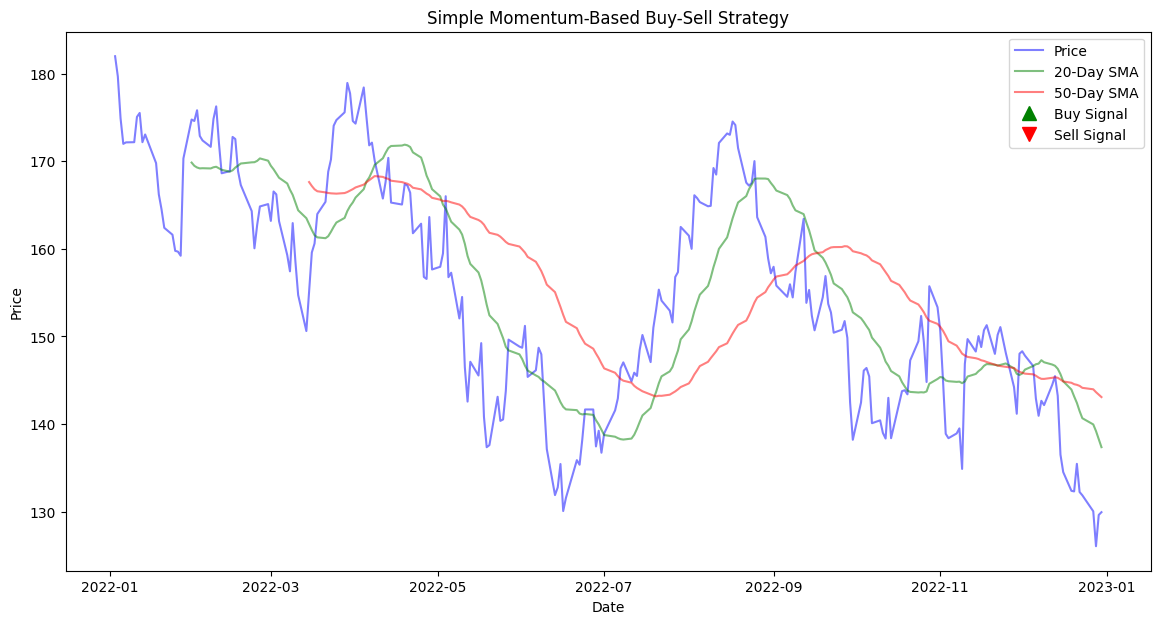

In [6]:
plt.figure(figsize=(14,7))
plt.plot(data["Close"], label="Price", color="blue", alpha=0.5)
plt.plot(data["SMA20"], label="20-Day SMA", color="green", alpha=0.5)
plt.plot(data["SMA50"], label="50-Day SMA", color="red", alpha=0.5)
plt.plot(data[data["Position"] == 1].index, data["SMA20"][data["Position"] == 1], "^", markersize=10, color="g", label="Buy Signal")
plt.plot(data[data["Position"] == -1].index, data["SMA20"][data["Position"] == -1], "v", markersize=10, color="r", label="Sell Signal")
plt.title("Simple Momentum-Based Buy-Sell Strategy")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


This code creates a plot showing:

The closing price of AAPL.
The 20-day and 50-day SMAs.
Buy signals (green upward arrows) where the position changes to 1.
Sell signals (red downward arrows) where the position changes to -1.

Price Line (Blue): This line shows the actual price movements of a stock or other asset over time.

20-Day SMA (Green): This moving average line smooths out price data by averaging the asset's closing prices over the past 20 days, making short-term trends clearer.

50-Day SMA (Red): This is a longer-term average that smooths out price data over the past 50 days, revealing longer-term trends.

Buy and Sell Signals:

Green Upward Triangle (Buy Signal): When the 20-day SMA (green line) crosses above the 50-day SMA (red line), it generates a "buy" signal. This crossover suggests that the short-term price momentum is stronger than the long-term trend, potentially indicating an upward movement.
Red Downward Triangle (Sell Signal): Conversely, when the 20-day SMA crosses below the 50-day SMA, it generates a "sell" signal. This crossover suggests a potential downward trend as short-term momentum weakens relative to the long-term trend.
Interpretation:
The graph suggests a momentum-based trading strategy that buys when the short-term trend (20-day SMA) shows strength by crossing above the long-term trend (50-day SMA) and sells when it weakens by crossing below.
The moving average crossovers act as triggers for entering and exiting positions, aiming to capture the medium-term trend movements in the asset price.

**Interpretation:**
The graph suggests a momentum-based trading strategy that buys when the short-term trend (20-day SMA) shows strength by crossing above the long-term trend (50-day SMA) and sells when it weakens by crossing below.
The moving average crossovers act as triggers for entering and exiting positions, aiming to capture the medium-term trend movements in the asset price.

## EXAMPLE 2:  Stock price analysis with sentiment analysis to build a simple trading strategy for Tesla's stock (TSLA) using moving averages and sentiment signals.

# 1. Imports

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
from transformers import pipeline
import matplotlib.pyplot as plt

# 2. Collecting Price Data

In [8]:
data = yf.download("TSLA", start="2022-01-01", end="2023-01-01")
data["SMA10"] = data["Close"].rolling(window=10).mean()
data["SMA50"] = data["Close"].rolling(window=50).mean()

[*********************100%***********************]  1 of 1 completed


Downloads Tesla's stock data (TSLA) for the specified date range.
Calculates two simple moving averages (SMAs):
SMA10: 10-day moving average of the closing price.
SMA50: 50-day moving average of the closing price.
These moving averages are often used in trading to identify momentum. For example, if the short-term average (SMA10) is above the long-term average (SMA50), it suggests an upward momentum.

# 3. Sentiment Analysis with NLP Model

In [9]:
sentiment_pipeline = pipeline("sentiment-analysis")
sample_texts = ["Tesla stock rises after positive earnings report", "Market fears growing recession"]
sentiment_scores = [sentiment_pipeline(text)[0]["label"] for text in sample_texts]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Sets up a sentiment analysis pipeline using a pre-trained model from the transformers library.
Defines sample text data that simulates news headlines or other textual data. Here, it uses two sample headlines.
Runs the sentiment analysis on each sample text, getting a label (POSITIVE or NEGATIVE) indicating the sentiment of each text.

# 4. Combining Sentiment Score and Momentum Signals

In [10]:
repeat_count = len(data) // len(sentiment_scores)
remainder = len(data) % len(sentiment_scores)
repeated_sentiment_scores = sentiment_scores * repeat_count + sentiment_scores[:remainder]
data["Sentiment"] = [1 if score == "POSITIVE" else -1 for score in repeated_sentiment_scores]

This part creates a sentiment signal for each date:

Repeats the sentiment scores to cover the entire dataset by aligning the sentiment data with the stock data length.
Converts POSITIVE sentiment to 1 and NEGATIVE sentiment to -1, assigning these values to the Sentiment column in data.

Generating Buy and Sell Signals

In [11]:
data["Signal"] = 0
data["Signal"] = np.where((data["SMA10"] > data["SMA50"]) & (data["Sentiment"] > 0), 1, 0)

Here, a buy signal is generated when:

The 10-day SMA is above the 50-day SMA, indicating upward momentum.
The sentiment score is positive.
The buy signal is represented by 1 in the Signal column, and no signal (0) otherwise.

Plotting the Graph

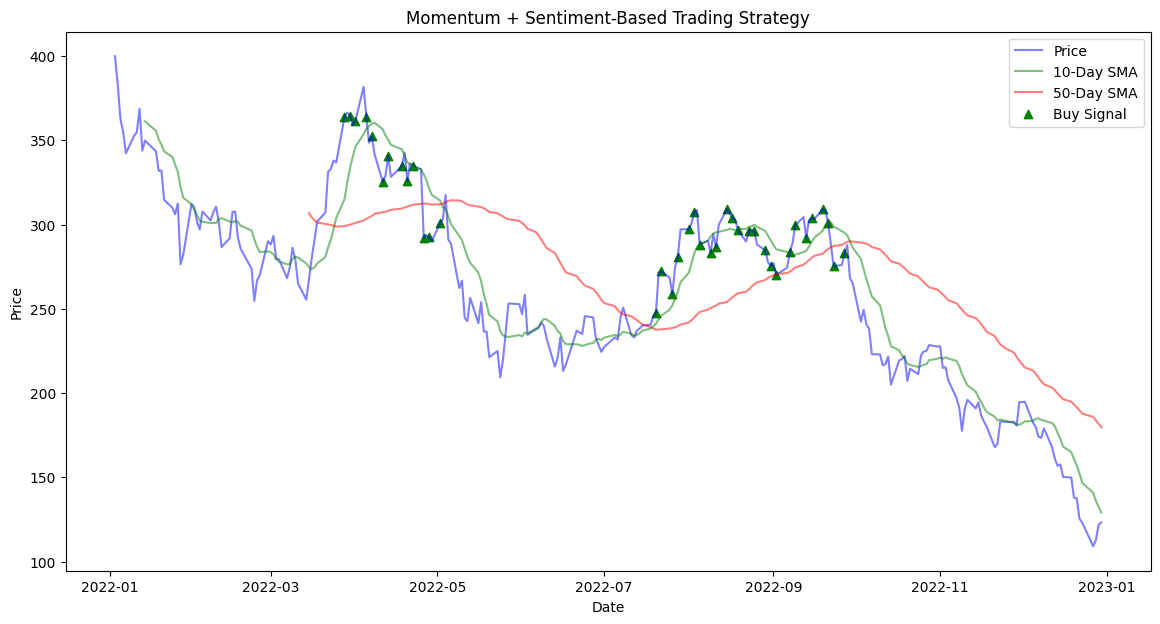

In [12]:
plt.figure(figsize=(14, 7))
plt.plot(data["Close"], label="Price", color="blue", alpha=0.5)
plt.plot(data["SMA10"], label="10-Day SMA", color="green", alpha=0.5)
plt.plot(data["SMA50"], label="50-Day SMA", color="red", alpha=0.5)
plt.scatter(data[data["Signal"] == 1].index, data["Close"][data["Signal"] == 1], marker="^", color="g", label="Buy Signal")
plt.title("Momentum + Sentiment-Based Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

This visualization shows:

The closing price of Tesla stock over time.
The 10-day and 50-day SMAs, which help identify trends.
Buy signals, represented by green upward arrows (where both SMA and sentiment criteria are met).
This combination of moving averages and sentiment analysis aims to buy when both technical and sentiment indicators are favorable.

Price Line (Blue): This line shows the price movement of an asset over time.

10-Day SMA (Green): This short-term simple moving average smooths out recent price movements over a 10-day period, highlighting short-term trends.

50-Day SMA (Red): This longer-term simple moving average smooths price data over a 50-day period, providing a broader perspective on the trend.

Buy Signals (Green Upward Triangles): These signals indicate points where the model suggests buying. The presence of multiple buy signals implies that sentiment analysis is likely incorporated into the strategy, potentially based on favorable sentiment patterns in addition to price movements.

**Interpretation:**
The 10-day SMA and 50-day SMA crossover strategy is combined with sentiment analysis. Typically, a crossover where the 10-day SMA crosses above the 50-day SMA would be a buy signal in a pure momentum-based strategy. However, here we see additional buy signals, likely influenced by positive sentiment indicators.
The frequent buy signals during some periods (e.g., mid-2022) suggest that sentiment analysis is actively contributing to the strategy, potentially indicating higher sentiment-driven buying opportunities, even without a standard SMA crossover.